In [21]:
import sys
sys.path.append('..')

In [ ]:
import numpy as np
from numcodecs import Blosc, BitRound

train_paths = [
    "..\\data\\DEMs\\train_dl\\20201201_0600.npz",
    "..\\data\\DEMs\\train_dl\\20230117_1200.npz",
    "..\\data\\DEMs\\train_dl\\20240815_0300.npz",
    "..\\data\\DEMs\\train_dl\\20250321_1200.npz",
    "..\\data\\DEMs\\train_dl\\20260630_1200.npz"
]
test_path = "..\\data\\DEMs\\20240520_1200.npz"   # esta NUNCA entra al loop de arriba 

dem_compressor = Blosc(cname='zstd', clevel=5, shuffle=2)
aia_compressor = Blosc(cname='zstd', clevel=4, shuffle=2)
dem_filter = BitRound(keepbits=12)

def load_and_align(npz_path):
    """Carga un .npz, decodifica los arrays comprimidos, y decima AIA/errores
    para que coincidan con la grilla de DEMCube."""
    npz = np.load(npz_path)

    DEMCubeShape = tuple(npz['DEMCubeShape'])
    DEMCube = np.frombuffer(
        dem_filter.decode(dem_compressor.decode(npz['DEMCube'].tobytes())),
        dtype=np.float32
    ).reshape(DEMCubeShape)

    AIACubeShape = tuple(npz['AIACubeShape'])
    AIACube = np.frombuffer(
        aia_compressor.decode(npz['AIACube'].tobytes()), dtype=np.float32
    ).reshape(AIACubeShape)
    AIAErrors = np.frombuffer(
        aia_compressor.decode(npz['AIAErrors'].tobytes()), dtype=np.float32
    ).reshape(AIACubeShape)

    decimate = AIACubeShape[1] // DEMCubeShape[1]
    if decimate > 1:
        AIACube = AIACube[:, ::decimate, ::decimate]
        AIAErrors = AIAErrors[:, ::decimate, ::decimate]

    assert AIACube.shape[1:] == DEMCube.shape[1:]
    return AIACube, AIAErrors, DEMCube

In [16]:
def cube_to_pixels(AIACube, AIAErrors):
    """(C,H,W) -> (N_validos, C), descartando píxeles con NaN en algún canal"""
    C, H, W = AIACube.shape
    aia_flat = AIACube.reshape(C, -1).T      # (H*W, C)
    err_flat = AIAErrors.reshape(C, -1).T    # (H*W, C)
    valid = ~np.isnan(aia_flat).any(axis=1)
    return aia_flat[valid], err_flat[valid]

all_aia, all_err = [], []
for p in train_paths:
    AIACube, AIAErrors, _ = load_and_align(p)
    aia_px, err_px = cube_to_pixels(AIACube, AIAErrors)
    all_aia.append(aia_px)
    all_err.append(err_px)

train_aia = np.concatenate(all_aia, axis=0)   # (N_total, 6)
train_err = np.concatenate(all_err, axis=0)
print("pixeles de entrenamiento:", train_aia.shape)

pixeles de entrenamiento: (1280, 6)


In [17]:
import torch
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cpu")

train_aia_t = torch.from_numpy(train_aia).double()
train_err_t = torch.from_numpy(train_err).double()

train_dataset = TensorDataset(train_aia_t, train_err_t)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)

In [18]:
import torch.nn.functional as F

class BarrierLoss(torch.nn.Module):
    def __init__(self, D, tolfac=1.4, alpha_l1=1e-3):
        super().__init__()
        self.D = D              # (n_channels, n_bins) = R directamente
        self.tolfac = tolfac
        self.alpha_l1 = alpha_l1

    def forward(self, dem_pred, aia_obs, aia_err):
        # dem_pred: (B, 18), aia_obs / aia_err: (B, 6)
        tol = aia_err * self.tolfac
        lb = aia_obs - tol
        ub = aia_obs + tol

        Dx = dem_pred @ self.D.T                       # (B, 6): resíntesis
        lb_check = torch.sum(torch.relu(lb - Dx), dim=1)
        ub_check = torch.sum(torch.relu(Dx - ub), dim=1)

        l1 = torch.sum(torch.abs(dem_pred), dim=1)

        return (lb_check + ub_check + self.alpha_l1 * l1).mean()

In [26]:
RData_raw = np.load("../RData.npz") 
R, logT = RData_raw['R'], RData_raw['logT']

print("R original:", R.shape)
print("logT:", logT.shape)         

# Escalar R 
scale = 10**26
R = (R * scale).astype(np.float64)
R = torch.from_numpy(R).double()
R.requires_grad_(False)

R original: (6, 18)
logT: (18,)


tensor([[6.4540e-03, 2.1109e-02, 5.3249e-02, 1.0293e-01, 1.5874e-01, 1.9217e-01,
         2.1668e-01, 2.4381e-01, 1.2726e-01, 3.3808e-02, 2.8772e-02, 7.0798e-02,
         1.5555e-01, 2.5149e-01, 2.6601e-01, 1.5263e-01, 3.9438e-02, 6.3700e-03],
        [1.1792e+00, 2.5208e+00, 3.7090e+00, 3.6225e+00, 2.4727e+00, 1.1970e+00,
         5.1393e-01, 2.6624e-01, 1.5653e-01, 1.0863e-01, 8.3812e-02, 6.7619e-02,
         6.0570e-02, 9.7103e-02, 3.9680e-01, 1.2448e+00, 1.4121e+00, 5.7931e-01],
        [6.3242e+00, 1.2171e+01, 3.9869e+01, 8.7808e+01, 1.2091e+02, 9.5002e+01,
         3.6421e+01, 6.9465e+00, 2.3151e+00, 1.9331e+00, 3.8375e-01, 1.3046e-01,
         1.0202e-01, 6.0220e-02, 4.5921e-02, 4.6042e-02, 3.8346e-02, 2.9827e-02],
        [8.6003e+00, 8.4959e+00, 1.2256e+01, 1.5591e+01, 1.8791e+01, 2.8653e+01,
         5.4574e+01, 6.2406e+01, 2.2004e+01, 2.7267e+00, 8.8299e-01, 7.1058e-01,
         7.6691e-01, 6.5511e-01, 3.3973e-01, 2.6987e-01, 9.6298e-01, 1.9560e+00],
        [2.2714e+00, 2.1

In [30]:
from src.model import DemoModel

model = DemoModel().double().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

loss_fn = BarrierLoss(D=R, tolfac=1.4, alpha_l1=1e-3)

def forward_pixelwise(model, x):
    x4 = x.unsqueeze(-1).unsqueeze(-1)     # (B, C) -> (B, C, 1, 1)
    out4 = model(x4)                        # (B, 18, 1, 1)
    return out4.squeeze(-1).squeeze(-1)     # (B, 18)

In [31]:
n_epochs = 500

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for aia_batch, err_batch in train_loader:
        optimizer.zero_grad()

        raw_output = forward_pixelwise(model, aia_batch)
        dem_pred = F.softplus(raw_output)

        loss = loss_fn(dem_pred, aia_batch, err_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * aia_batch.shape[0]

    epoch_loss /= len(train_dataset)
    print(f"epoch {epoch+1}/{n_epochs}  loss: {epoch_loss:.4f}")

epoch 1/500  loss: 377.4387
epoch 2/500  loss: 309.4401
epoch 3/500  loss: 285.5263
epoch 4/500  loss: 266.4748
epoch 5/500  loss: 247.8325
epoch 6/500  loss: 228.1753
epoch 7/500  loss: 208.8561
epoch 8/500  loss: 190.0306
epoch 9/500  loss: 175.2487
epoch 10/500  loss: 161.1632
epoch 11/500  loss: 145.5613
epoch 12/500  loss: 133.4193
epoch 13/500  loss: 122.2496
epoch 14/500  loss: 112.4976
epoch 15/500  loss: 104.2746
epoch 16/500  loss: 100.6229
epoch 17/500  loss: 100.6008
epoch 18/500  loss: 104.4124
epoch 19/500  loss: 87.4171
epoch 20/500  loss: 78.5165
epoch 21/500  loss: 71.6347
epoch 22/500  loss: 67.0997
epoch 23/500  loss: 63.3036
epoch 24/500  loss: 60.8182
epoch 25/500  loss: 58.5026
epoch 26/500  loss: 58.8457
epoch 27/500  loss: 52.5294
epoch 28/500  loss: 48.3446
epoch 29/500  loss: 50.1490
epoch 30/500  loss: 47.6880
epoch 31/500  loss: 43.4165
epoch 32/500  loss: 44.2016
epoch 33/500  loss: 42.0606
epoch 34/500  loss: 40.5846
epoch 35/500  loss: 40.5761
epoch 36/50

In [32]:
AIACube_test, AIAErrors_test, DEMCube_test = load_and_align(test_path)
aia_test_px, err_test_px = cube_to_pixels(AIACube_test, AIAErrors_test)

aia_test_t = torch.from_numpy(aia_test_px).double()
err_test_t = torch.from_numpy(err_test_px).double()

model.eval()
with torch.no_grad():
    raw_test = forward_pixelwise(model, aia_test_t)
    dem_test_pred = F.softplus(raw_test)
    test_loss = loss_fn(dem_test_pred, aia_test_t, err_test_t)

print("loss en test (imagen independiente):", test_loss.item())

loss en test (imagen independiente): 5.976664825250941


In [ ]:
DEMCube_test = torch.from_numpy(DEMCube_test).float()  

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10180\4006415503.py:1: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  DEMCube_test = torch.from_numpy(DEMCube_test).float()  # o double si usas double


In [41]:
DEMCube_test.shape, dem_test_pred.shape

(torch.Size([18, 16, 16]), torch.Size([256, 18]))

In [43]:
H, W = DEMCube_test.shape[1:]
DEMCube_pred = dem_test_pred.reshape(H, W, -1).permute(2, 0, 1)

In [45]:
DEMCube_test.shape, DEMCube_pred.shape

(torch.Size([18, 16, 16]), torch.Size([18, 16, 16]))

In [46]:
def style_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

import matplotlib.pyplot as plt

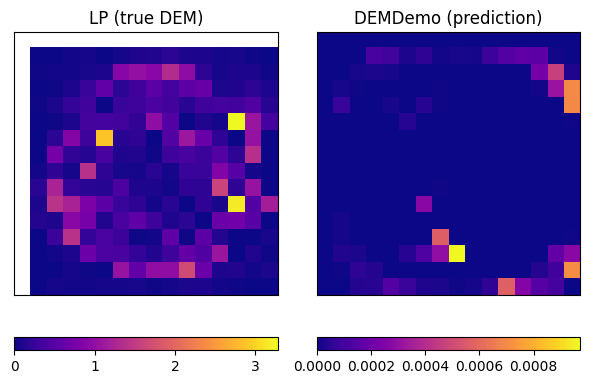

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(6, 4))

# True DEM
im0 = axes[0].imshow(DEMCube_test[5].numpy(), cmap='plasma')
axes[0].set_title("LP (true DEM)")
style_ax(axes[0])

cbar0 = fig.colorbar(im0, ax=axes[0], orientation='horizontal', pad=0.12, fraction=0.046)

# Pred DEM
im1 = axes[1].imshow(DEMCube_pred[5].numpy(), cmap='plasma')
axes[1].set_title("DEMDemo (prediction)")
style_ax(axes[1])

cbar1 = fig.colorbar(im1, ax=axes[1], orientation='horizontal', pad=0.12, fraction=0.046)

plt.tight_layout()
plt.show()

In [62]:
from scipy.spatial.distance import jensenshannon

def js_map(dem1: np.ndarray, dem2: np.ndarray) -> np.ndarray:
    _, H, W = dem1.shape
    dist_map = np.zeros((H, W))

    for i in range(H):
        for j in range(W):
            w1 = dem1[:, i, j]
            w2 = dem2[:, i, j]

            if not (np.isfinite(w1).all() and np.isfinite(w2).all()):
                dist_map[i, j] = np.nan
                continue

            dist_map[i, j] = jensenshannon(w1, w2)

    return dist_map

In [63]:
js_map = js_map(DEMCube_test.squeeze(0).numpy(), DEMCube_pred.squeeze(0).numpy())

c:\Users\Usuario\anaconda3\envs\dem-dl\Lib\site-packages\scipy\spatial\distance.py:1280: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)


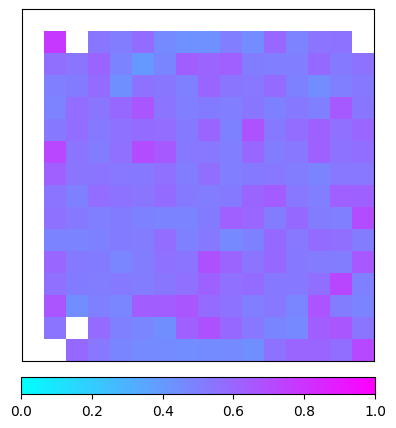

In [64]:
fig, ax = plt.subplots(figsize=(5, 5))

img = ax.imshow(js_map, cmap='cool', vmin=0, vmax=1)

style_ax(ax)

fig.colorbar(
    img,
    ax=ax,
    orientation='horizontal',
    fraction=0.046,
    pad=0.04,
)

plt.show()